# Aeon with `movement`

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
from aeon.dj_pipeline import fetch_stream, streams, tracking
from matplotlib import pyplot as plt
from movement.filtering import (
    filter_by_confidence,
    interpolate_over_time,
    rolling_filter,
)
from movement.kinematics import compute_speed, compute_forward_vector, compute_forward_vector_angle, compute_pairwise_distances
from movement.transforms import scale
from movement.plots import plot_centroid_trajectory, plot_occupancy
from movement.io.load_poses import from_numpy
from movement.utils.vector import cart2pol
from scipy.signal import welch
from swc.aeon.io import api as io_api
from swc.aeon.io import reader as io_reader

## Utility functions

In [400]:
def pose_df_to_movement_ds(pose: pd.DataFrame) -> xr.Dataset:
    """
    Convert a DataFrame containing pose data to a `movement` poses dataset.

    Parameters
    ----------
    pose : pd.DataFrame
        DataFrame containing pose data with columns ['time', 'part', 'identity', 'x', 'y', 'part_likelihood'].

    Returns
    -------
    xarray.Dataset
        movement-compatible xarray.Dataset containing pose estimation data.
    """
    # Convert index to seconds and infer FPS
    pose = pose.copy()
    timestamps = pose.index.drop_duplicates().to_series()
    pose.index = (pose.index - pose.index[0]).total_seconds()
    frames = pose.index.drop_duplicates().to_numpy()
    mean_time_diff = np.diff(frames).mean()
    fps = float(np.ceil(1 / mean_time_diff)) if mean_time_diff > 0 else None
    keypoints = pose["part"].unique()
    individuals = pose["identity"].unique()
    # Create position array
    multi_idx = pd.MultiIndex.from_product(
        [frames, keypoints, individuals], names=["frame", "part", "identity"]
    )
    pose_reset = pose.reset_index().set_index(["time", "part", "identity"])
    pose_full = pose_reset.reindex(multi_idx)
    x_arr = pose_full["x"].values.reshape(len(frames), len(keypoints), len(individuals))
    y_arr = pose_full["y"].values.reshape(len(frames), len(keypoints), len(individuals))
    pose_arr = np.stack([x_arr, y_arr], axis=1).astype(float)
    # Create confidence array
    conf_arr = pose_full["part_likelihood"].values.reshape(
        len(frames), len(keypoints), len(individuals)
    )
    ds = from_numpy(
        position_array=pose_arr,
        confidence_array=conf_arr,
        individual_names=individuals,
        keypoint_names=keypoints,
        fps=fps,
    )
    ds = ds.assign_coords({"time": timestamps, "seconds_elapsed": ("time", frames)})
    ds.attrs["time_unit"] = timestamps.dtype.name
    return ds


def plot_confidence_hist(ds: xr.Dataset, vlines: list = None) -> None:
    """
    Plot histograms of confidence values for each keypoint in the dataset.

    Parameters
    ----------
    ds : xr.Dataset
        The dataset containing keypoint positions and confidence values.
    vlines : list, optional
        List of x-values at which to draw vertical lines (e.g. to
        visualise thresholds). Default is None.
    """
    n_keypoints = ds.sizes["keypoints"]
    # Create subplots for each keypoint
    fig, axes = plt.subplots(
        nrows=2,
        ncols=(n_keypoints + 1) // 2,
        figsize=(n_keypoints * 1.5, n_keypoints * 0.75),
        sharey=True,
        sharex=True,
    )
    for i, kpt in enumerate(ds.keypoints.values):
        ax = axes[i % 2, i // 2]
        for j, ind in enumerate(ds.individuals.values):
            ds.confidence.sel(keypoints=kpt, individuals=ind).plot.hist(
                bins=20,
                ax=ax,
                label=ind,
                histtype="stepfilled",
                fill=False,
                edgecolor=f"C{j}",  # Use matplotlib color cycle for edge
                density=True,
            )
        # Add vertical lines if specified
        if vlines is not None:
            for vline in vlines:
                ax.axvline(vline, color="k", linestyle="--", linewidth=1)
        ax.set_ylabel("Density")
        ax.set_xlabel("")
        ax.set_xlabel("Confidence")
        ax.set_title(kpt)
        ax.legend()
    plt.suptitle("Confidence Histograms by Keypoint and Individual")
    plt.tight_layout()


def plot_speed(da: xr.DataArray) -> None:
    """
    Plot speed over time and a histogram of the speed values.

    This function creates a line plot of speed over time for each individual
    in the dataset, along with a histogram of the speed values.

    Parameters
    ----------
    da: xr.DataArray
        The data array containing speed data.

    """
    individuals = da.individuals.values.tolist() if "individuals" in da.dims else [None]
    n_individuals = len(individuals)
    fig, axes = plt.subplots(
        n_individuals,
        2,
        figsize=(12, 4 * n_individuals),
        squeeze=False,
        gridspec_kw={"width_ratios": [4, 1]},
    )
    for i, ind in enumerate(individuals):
        if ind is not None:
            da_ind = da.sel(individuals=ind)
            label = ind
        else:
            da_ind = da
            label = None
        ax, ax_hist = axes[i]
        keypoints_label = (
            da_ind.keypoints.values if "keypoints" in da_ind.dims else None
        )
        da_ind.plot.line(x="time", lw=0.5, ax=ax, label=keypoints_label)
        ax.set_title(f"Speed vs time: {label}")
        ax.set_ylabel("Speed (cm/s)")
        ax.set_xlabel("Datetime")
        ax.set_xlim(
            da_ind.time.min().values,
            da_ind.time.max().values,
        )
        if keypoints_label is not None:
            ax.legend()
        # Plot histogram of speed
        da_ind.plot.hist(bins=25, orientation="horizontal", ax=ax_hist)
        ax_hist.set_title("Histogram")
        ax_hist.set_xscale("log")
        ax_hist.set_xlabel("log count")
    plt.tight_layout()


def plot_raw_and_smooth_timeseries_and_psd(
    da_raw: xr.DataArray,
    da_smooth: xr.DataArray,
    fps: float,
    individual: str = None,
    keypoint: str = None,
    space: str = "x",
    time_range: slice = None,
) -> None:
    """
    Plot raw and smoothed time series of a keypoint's position
    and their Power Spectral Density (PSD).

    Parameters
    ----------
    da_raw : xr.DataArray
        The data array containing raw keypoint positions.
    da_smooth : xr.DataArray
        The data array containing smoothed keypoint positions.
    fps : float
        The frames per second of the data.
    individual : str, optional
        The individual to plot. If None, the first individual is used.
    keypoint : str, optional
        The keypoint to plot. If None, the first keypoint is used.
    space : str, optional
        The spatial dimension to plot (e.g., "x" or "y"). Default is "x".
    time_range : slice, optional
        The time range to plot. If None, the entire time series is plotted.
    """

    # If no time range is specified, plot the entire time series
    if time_range is None:
        time_range = slice(0, da_raw.time[-1])
    if individual is None:
        individual = da_raw.individuals.values[0]
    if keypoint is None:
        keypoint = da_raw.keypoints.values[0]
    selection = {
        "time": time_range,
        "individuals": individual,
        "keypoints": keypoint,
        "space": space,
    }
    fig, ax = plt.subplots(2, 1, figsize=(8, 6))
    for da, color, label in zip(
        [da_raw, da_smooth], ["k", "r"], ["raw", "smooth"], strict=False
    ):
        # plot position time series
        pos = da.sel(**selection)
        ax[0].plot(
            pos.time,
            pos,
            color=color,
            lw=2,
            alpha=0.7,
            label=f"{label} {space}",
        )
        # interpolate data to remove NaNs in the PSD calculation
        pos_interp = interpolate_over_time(pos, fill_value="extrapolate")
        # compute and plot the PSD
        freq, psd = welch(pos_interp, fs=fps, nperseg=256)
        ax[1].semilogy(
            freq,
            psd,
            color=color,
            lw=2,
            alpha=0.7,
            label=f"{label} {space}",
        )
    ax[0].set_ylabel(f"{space} position (px)")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_title("Time Domain")
    ax[0].legend()
    ax[1].set_ylabel("PSD (px$^2$/Hz)")
    ax[1].set_xlabel("Frequency (Hz)")
    ax[1].set_title("Frequency Domain")
    ax[1].legend()
    plt.suptitle(f"Keypoint: {keypoint}, Individual: {individual}, Space: {space}")
    plt.tight_layout()

def plot_polar_histogram(da, bin_width_deg=15, ax=None):
    """Plot a polar histogram of the data in the given DataArray.

    Parameters
    ----------
    da : xarray.DataArray
        A DataArray containing angle data in radians.
    bin_width_deg : int, optional
        Width of the bins in degrees.
    ax : matplotlib.axes.Axes, optional
        The axes on which to plot the histogram.

    """
    n_bins = int(360 / bin_width_deg)
    if ax is None:
        fig, ax = plt.subplots(  # initialise figure with polar projection
            1, 1, figsize=(5, 5), subplot_kw={"projection": "polar"}
        )
    else:
        fig = ax.figure  # or use the provided axes
    # plot histogram using xarray's built-in histogram function
    da.plot.hist(
        bins=np.linspace(-np.pi, np.pi, n_bins + 1), ax=ax, density=True
    )
    # axes settings
    ax.set_theta_direction(-1)  # theta increases in clockwise direction
    ax.set_theta_offset(0)  # set zero at the right
    ax.set_xlabel("")  # remove default x-label from xarray's plot.hist()
    # set xticks to match the phi values in degrees
    n_xtick_edges = 9
    ax.set_xticks(np.linspace(0, 2 * np.pi, n_xtick_edges)[:-1])
    xticks_in_deg = (
        list(range(0, 180 + 45, 45)) + list(range(0, -180, -45))[-1:0:-1]
    )
    ax.set_xticklabels([str(t) + "\N{DEGREE SIGN}" for t in xticks_in_deg])
    return fig, ax

## Load Aeon data into `xarray.Dataset`

In [58]:
start_time = pd.Timestamp("2024-02-09 17:00:00")
end_time = start_time + pd.Timedelta(minutes=10)

### Load from database

In [59]:
key = {
    "experiment_name": "social0.2-aeon3",
    "chunk_start": start_time,
    "spinnaker_video_source_name": "CameraTop",
}
pose_query = (
    streams.SpinnakerVideoSource
    * tracking.SLEAPTracking.PoseIdentity.proj("identity_name", anchor_part="part_name")
    * tracking.SLEAPTracking.Part
    & key
)
pose_db = fetch_stream(pose_query, drop_pk=False)[start_time:end_time]
pose_db = pose_db.rename(
    columns={
        "identity_name": "identity",
        "part_name": "part",
        "likelihood": "part_likelihood",
    }
)[["identity", "part", "x", "y", "part_likelihood"]]

[2025-05-30 10:06:31,733][WARNING]: Reconnecting to MySQL server.


In [66]:
pose_db

,identity,part,x,y,part_likelihood
time,,,,,
2024-02-09 17:00:00,BAA-1104045,head,216.261276,658.199707,0.913870
2024-02-09 17:00:00,BAA-1104045,nose,218.705017,662.463623,0.973795
2024-02-09 17:00:00,BAA-1104045,right_ear,212.391373,654.912659,0.802099
2024-02-09 17:00:00,BAA-1104045,spine1,215.793121,648.773987,0.920988
2024-02-09 17:00:00,BAA-1104045,spine2,215.949387,639.982117,0.954582
...,...,...,...,...,...
2024-02-09 17:10:00,BAA-1104047,right_ear,624.303284,722.340088,1.045787
2024-02-09 17:10:00,BAA-1104045,right_ear,211.794922,565.151550,1.000493
2024-02-09 17:10:00,BAA-1104047,nose,621.139282,714.663635,0.651423


### Load from ceph

In [53]:
root = "Z:/aeon/data/ingest"
pose_reader = io_reader.Pose("CameraTop_222*", root)
pose_ceph = io_api.load(
    root=f"{root}/AEON3/social0.2",
    reader=pose_reader,
    start=start_time,
    end=end_time,
    include_model=False,
)
pose_ceph = pose_ceph[~pose_ceph["part"].str.startswith("anchor_")]

In [54]:
pose_ceph

,identity,identity_likelihood,part,x,y,part_likelihood
time,,,,,,
2024-02-09 17:00:00,BAA-1104045,"{'BAA-1104045': 0.9994382, 'BAA-1104047': 0.00...",nose,218.705017,662.463623,0.973795
2024-02-09 17:00:00,BAA-1104045,"{'BAA-1104045': 0.9994382, 'BAA-1104047': 0.00...",head,216.261276,658.199707,0.91387
2024-02-09 17:00:00,BAA-1104045,"{'BAA-1104045': 0.9994382, 'BAA-1104047': 0.00...",right_ear,212.391373,654.912659,0.802099
2024-02-09 17:00:00,BAA-1104045,"{'BAA-1104045': 0.9994382, 'BAA-1104047': 0.00...",left_ear,219.657227,655.994568,1.094986
2024-02-09 17:00:00,BAA-1104045,"{'BAA-1104045': 0.9994382, 'BAA-1104047': 0.00...",spine1,215.793121,648.773987,0.920988
...,...,...,...,...,...,...
2024-02-09 17:10:00,BAA-1104047,"{'BAA-1104045': 0.00012735075, 'BAA-1104047': ...",left_ear,616.378418,719.120728,0.680203
2024-02-09 17:10:00,BAA-1104047,"{'BAA-1104045': 0.00012735075, 'BAA-1104047': ...",spine1,618.532166,727.029663,0.907356
2024-02-09 17:10:00,BAA-1104047,"{'BAA-1104045': 0.00012735075, 'BAA-1104047': ...",spine2,615.890747,736.231079,0.938028


### Convert pose DataFrame to movement Dataset

In [332]:
ds = pose_df_to_movement_ds(pose_db)
ds

<xarray.Dataset> Size: 12MB
Dimensions:          (space: 2, keypoints: 8, individuals: 2, time: 30001)
Coordinates:
  * space            (space) <U1 8B 'x' 'y'
  * keypoints        (keypoints) <U9 288B 'head' 'nose' ... 'spine4' 'left_ear'
  * individuals      (individuals) <U11 88B 'BAA-1104045' 'BAA-1104047'
  * time             (time) datetime64[ns] 240kB 2024-02-09T17:00:00 ... 2024...
    seconds_elapsed  (time) float64 240kB 0.0 0.02 0.04 ... 600.0 600.0 600.0
Data variables:
    position         (time, space, keypoints, individuals) float64 8MB 216.3 ...
    confidence       (time, keypoints, individuals) float64 4MB 0.9139 ... 0....
Attributes:
    source_software:  None
    ds_type:          poses
    fps:              50.0
    time_unit:        datetime64[ns]

## Plot confidence histograms per individual and keypoint

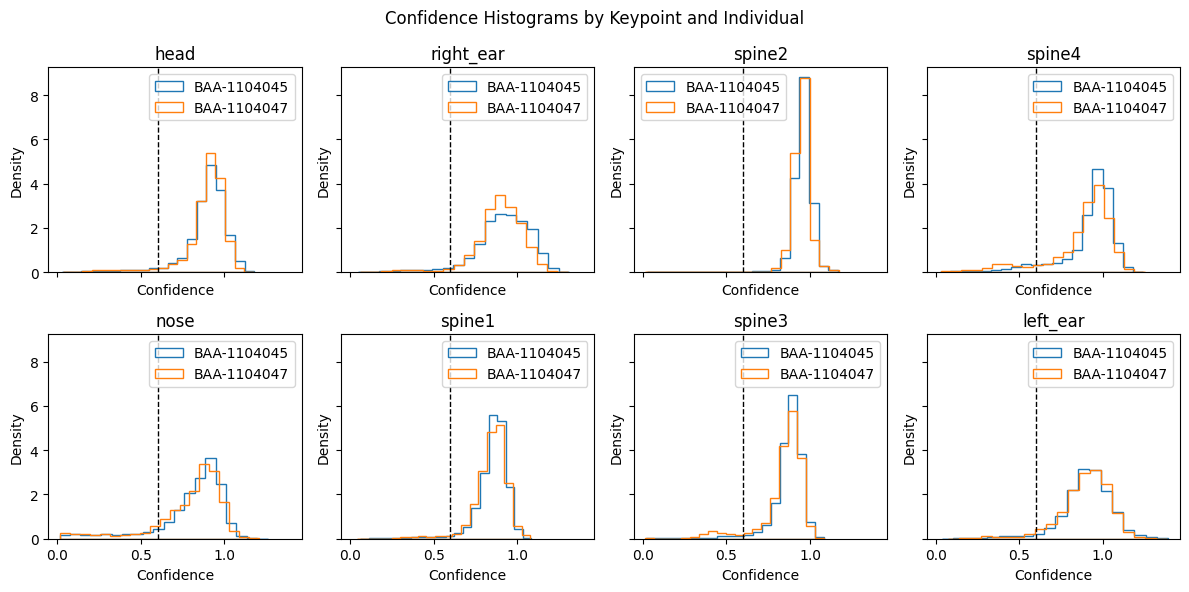

In [333]:
plot_confidence_hist(ds, vlines=[0.6])

### Filter out low-confidence keypoints

In [334]:
CONFIDENCE_THRESHOLD = 0.6
ds["position_filtered"] = filter_by_confidence(
    ds.position, ds.confidence, threshold=CONFIDENCE_THRESHOLD
)
ds.position_filtered.attrs["confidence_threshold"] = CONFIDENCE_THRESHOLD
ds["confidence_filtered"] = ds.confidence.where(ds.confidence >= CONFIDENCE_THRESHOLD)

In [335]:
ds

<xarray.Dataset> Size: 24MB
Dimensions:              (space: 2, keypoints: 8, individuals: 2, time: 30001)
Coordinates:
  * space                (space) <U1 8B 'x' 'y'
  * keypoints            (keypoints) <U9 288B 'head' 'nose' ... 'left_ear'
  * individuals          (individuals) <U11 88B 'BAA-1104045' 'BAA-1104047'
  * time                 (time) datetime64[ns] 240kB 2024-02-09T17:00:00 ... ...
    seconds_elapsed      (time) float64 240kB 0.0 0.02 0.04 ... 600.0 600.0
Data variables:
    position             (time, space, keypoints, individuals) float64 8MB 21...
    confidence           (time, keypoints, individuals) float64 4MB 0.9139 .....
    position_filtered    (time, space, keypoints, individuals) float64 8MB 21...
    confidence_filtered  (time, keypoints, individuals) float64 4MB 0.9139 .....
Attributes:
    source_software:  None
    ds_type:          poses
    fps:              50.0
    time_unit:        datetime64[ns]

## Plot line plots of all keypoints per individual over time

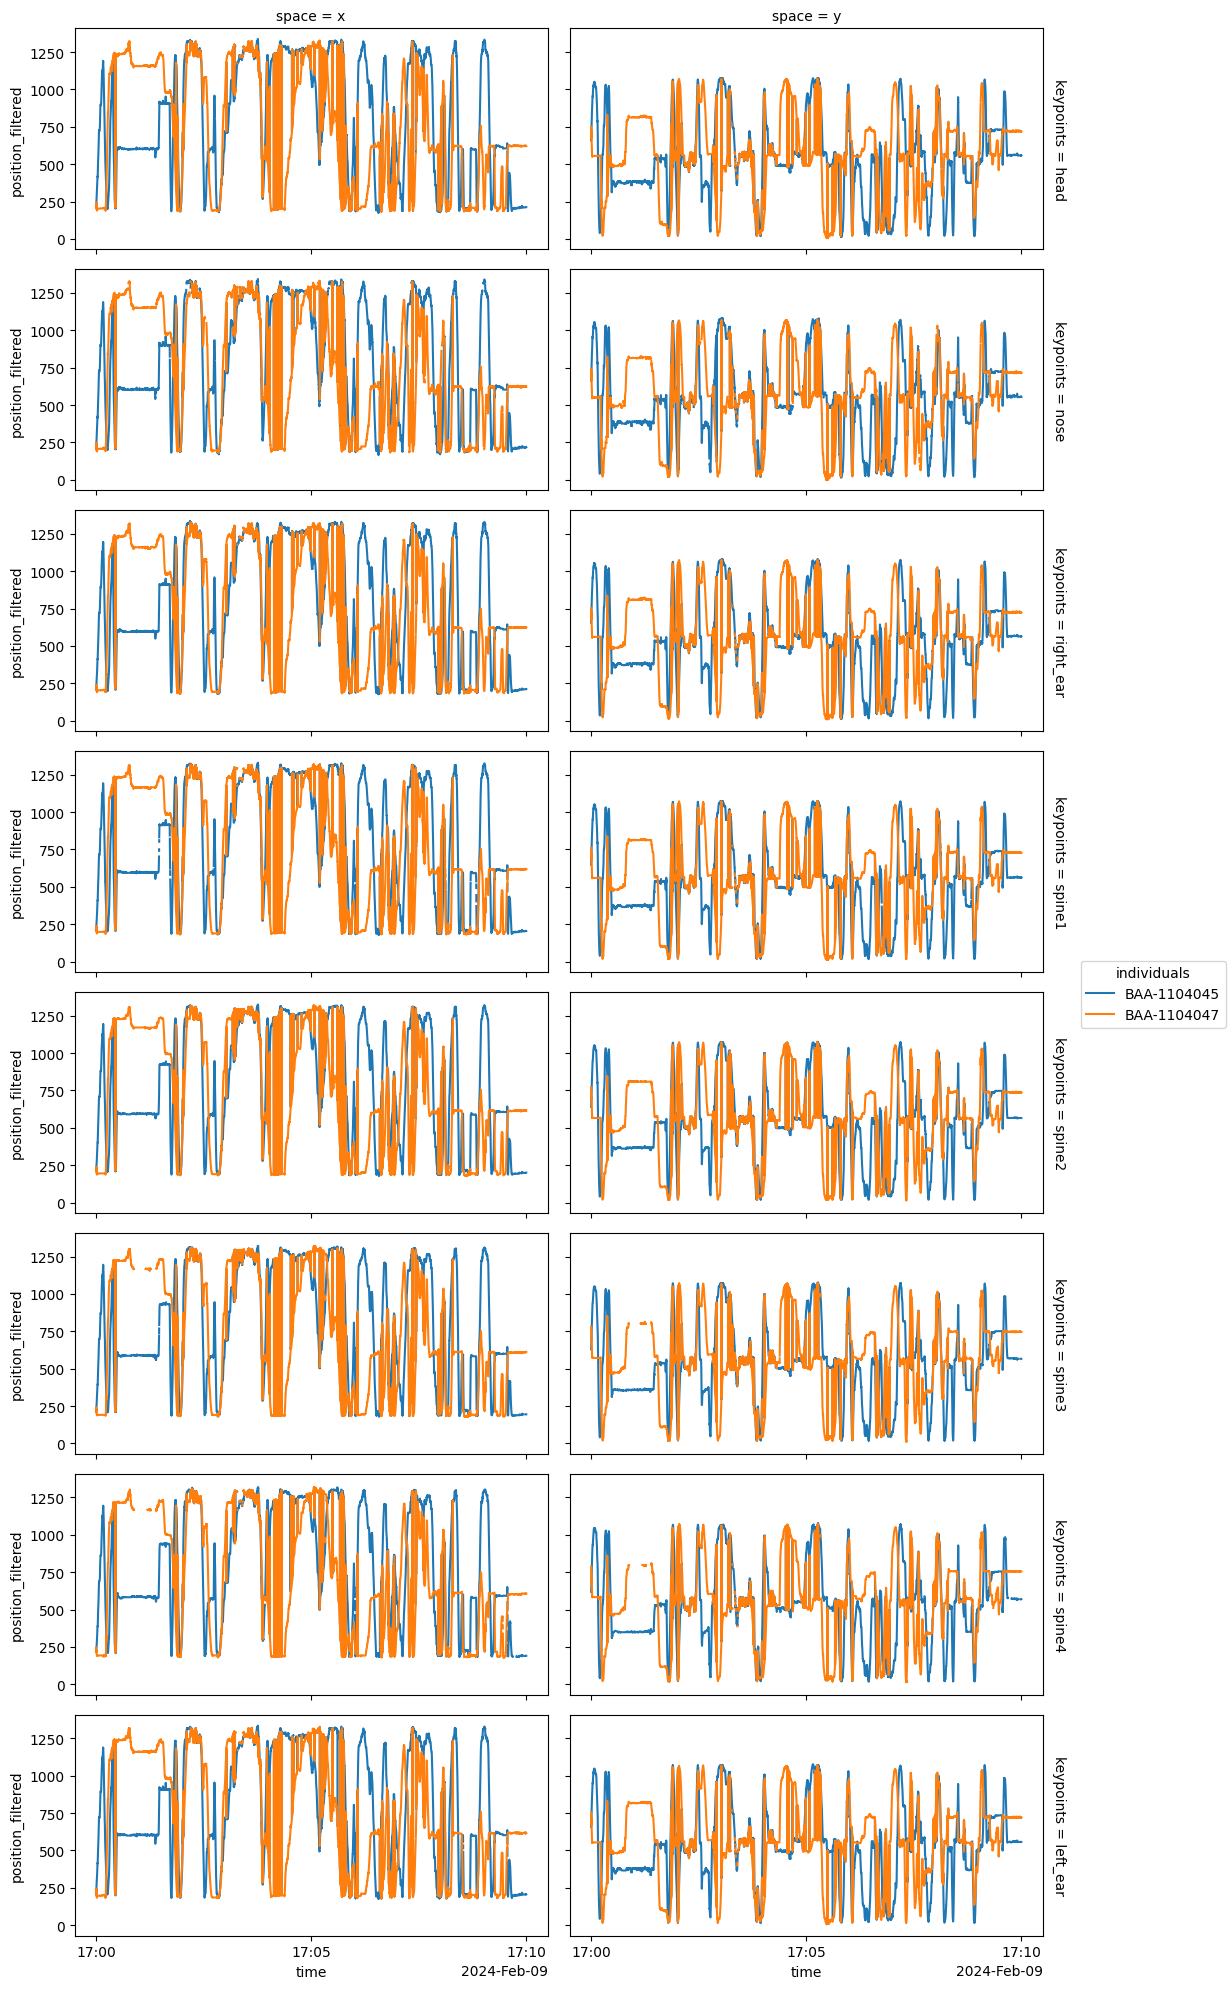

In [336]:
ds.position_filtered.plot.line(
    x="time",
    row="keypoints",
    col="space",
    hue="individuals",
    aspect=2,
    size=2.5
)
plt.subplots_adjust(right=0.85)

## Smoothing
### Median filter

In [337]:
window = int(0.5 * ds.fps)  # 0.5s window, 25 frames
ds["position_smooth"] = rolling_filter(
    ds.position_filtered,
    window,
    min_periods=5,  # Require at least 5 consecutive frames without NaN
    statistic="median",
    print_report=True,
)


Missing points (marked as NaN) in input
	Individual: BAA-1104045
		head: 1218/30001 (4.1%)
		nose: 3639/30001 (12.1%)
		right_ear: 1308/30001 (4.4%)
		spine1: 963/30001 (3.2%)
		spine2: 295/30001 (1.0%)
		spine3: 1053/30001 (3.5%)
		spine4: 2373/30001 (7.9%)
		left_ear: 1295/30001 (4.3%)
	Individual: BAA-1104047
		head: 1246/30001 (4.2%)
		nose: 4031/30001 (13.4%)
		right_ear: 1072/30001 (3.6%)
		spine1: 1018/30001 (3.4%)
		spine2: 89/30001 (0.3%)
		spine3: 2105/30001 (7.0%)
		spine4: 3358/30001 (11.2%)
		left_ear: 1332/30001 (4.4%)

Missing points (marked as NaN) in output
	Individual: BAA-1104045
		head: 315/30001 (1.0%)
		nose: 1243/30001 (4.1%)
		right_ear: 363/30001 (1.2%)
		spine1: 231/30001 (0.8%)
		spine2: 42/30001 (0.1%)
		spine3: 245/30001 (0.8%)
		spine4: 1063/30001 (3.5%)
		left_ear: 339/30001 (1.1%)
	Individual: BAA-1104047
		head: 548/30001 (1.8%)
		nose: 1697/30001 (5.7%)
		right_ear: 449/30001 (1.5%)
		spine1: 454/30001 (1.5%)
		spine2: 14/30001 (0.0%)
		spine3: 1443/3

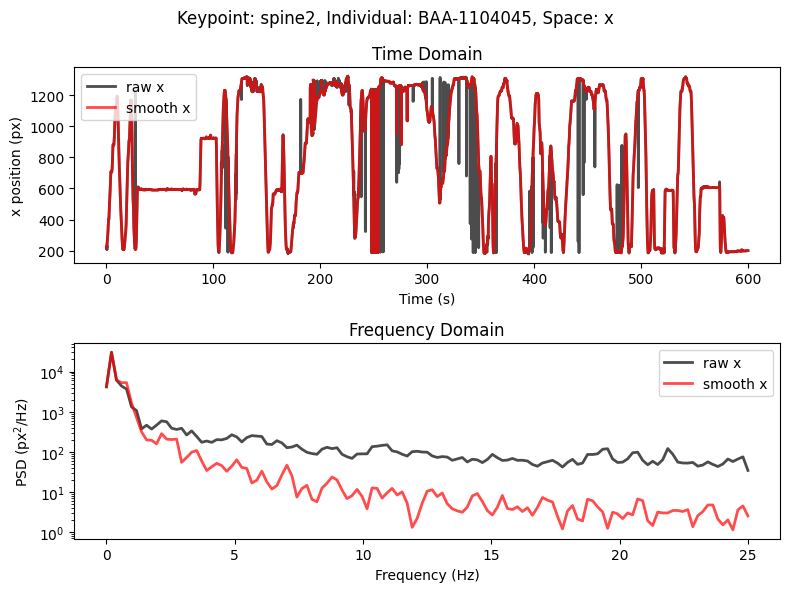

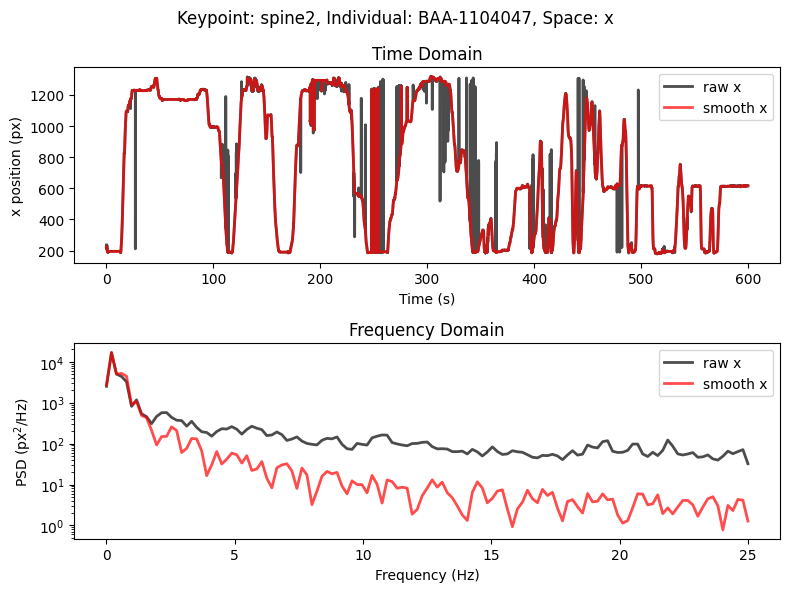

In [338]:
for ind in ds.individuals.values:
    plot_raw_and_smooth_timeseries_and_psd(
        ds.position_filtered.set_index(time="seconds_elapsed"),
        ds.position_smooth.set_index(time="seconds_elapsed"),
        fps=ds.fps,
        keypoint="spine2",
        individual=ind,
    )

## Plot speed (cm/s)
### Compute speed (cm/s)

1. Set the time index to "seconds_elapsed" to ensure that `compute_speed` and `scale` functions work correctly.
2. Scale the filtered position values to cm/s. 
3. Compute the speed based on the filtered and scaled position values.
4. Set the time index back to datetime and store `speed_cm_per_sec` in the same dataset.

In [339]:
PIXEL_SCALE = 0.192  # 1 px = 0.192 cm
# Compute speed in cm/s for both filtered and smoothed positions
ds["speed_cm_per_sec"] = compute_speed(
    scale(
        ds.position_filtered.set_index(time="seconds_elapsed"),
        factor=PIXEL_SCALE,
        space_unit="cm",
    )
).assign_coords(
    time=ds.time,
)
ds["speed_cm_per_sec_smooth"] = compute_speed(
    scale(
        ds.position_smooth.set_index(time="seconds_elapsed"),
        factor=PIXEL_SCALE,
        space_unit="cm",
    )
).assign_coords(
    time=ds.time,
)
ds

<xarray.Dataset> Size: 39MB
Dimensions:                  (space: 2, keypoints: 8, individuals: 2,
                              time: 30001)
Coordinates:
  * space                    (space) <U1 8B 'x' 'y'
  * keypoints                (keypoints) <U9 288B 'head' 'nose' ... 'left_ear'
  * individuals              (individuals) <U11 88B 'BAA-1104045' 'BAA-1104047'
  * time                     (time) datetime64[ns] 240kB 2024-02-09T17:00:00 ...
    seconds_elapsed          (time) float64 240kB 0.0 0.02 0.04 ... 600.0 600.0
Data variables:
    position                 (time, space, keypoints, individuals) float64 8MB ...
    confidence               (time, keypoints, individuals) float64 4MB 0.913...
    position_filtered        (time, space, keypoints, individuals) float64 8MB ...
    confidence_filtered      (time, keypoints, individuals) float64 4MB 0.913...
    position_smooth          (time, space, keypoints, individuals) float64 8MB ...
    speed_cm_per_sec         (time, keypoints, individuals) float64 4MB 5.526...
    speed_cm_per_sec_smooth  (time, keypoints, individuals) float64 4MB 0.0 ....
Attributes:
    source_software:  None
    ds_type:          poses
    fps:              50.0
    time_unit:        datetime64[ns]

### Plot `spine2` speed per individual
#### Filtered data points with confidence >= 0.6

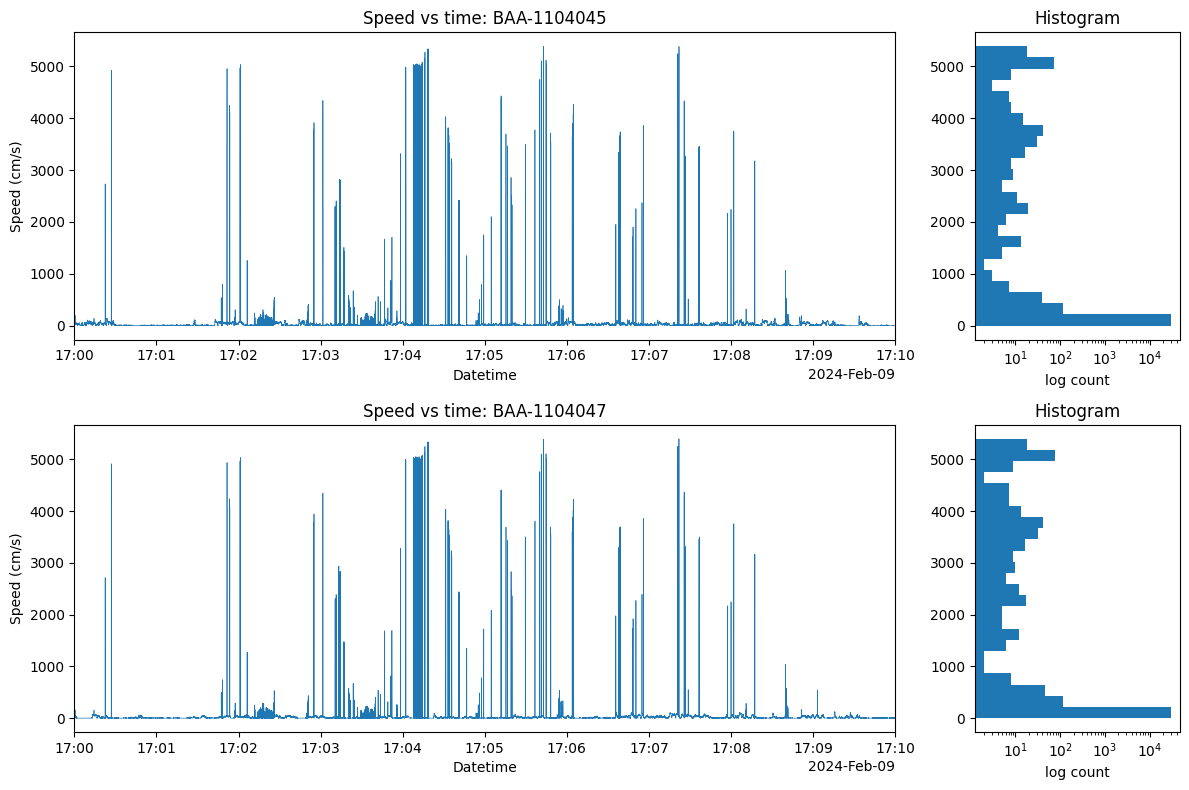

In [340]:
plot_speed(ds.speed_cm_per_sec.sel(keypoints="spine2"))

### Filtered data points with confidence >= 0.6 and median smoothing

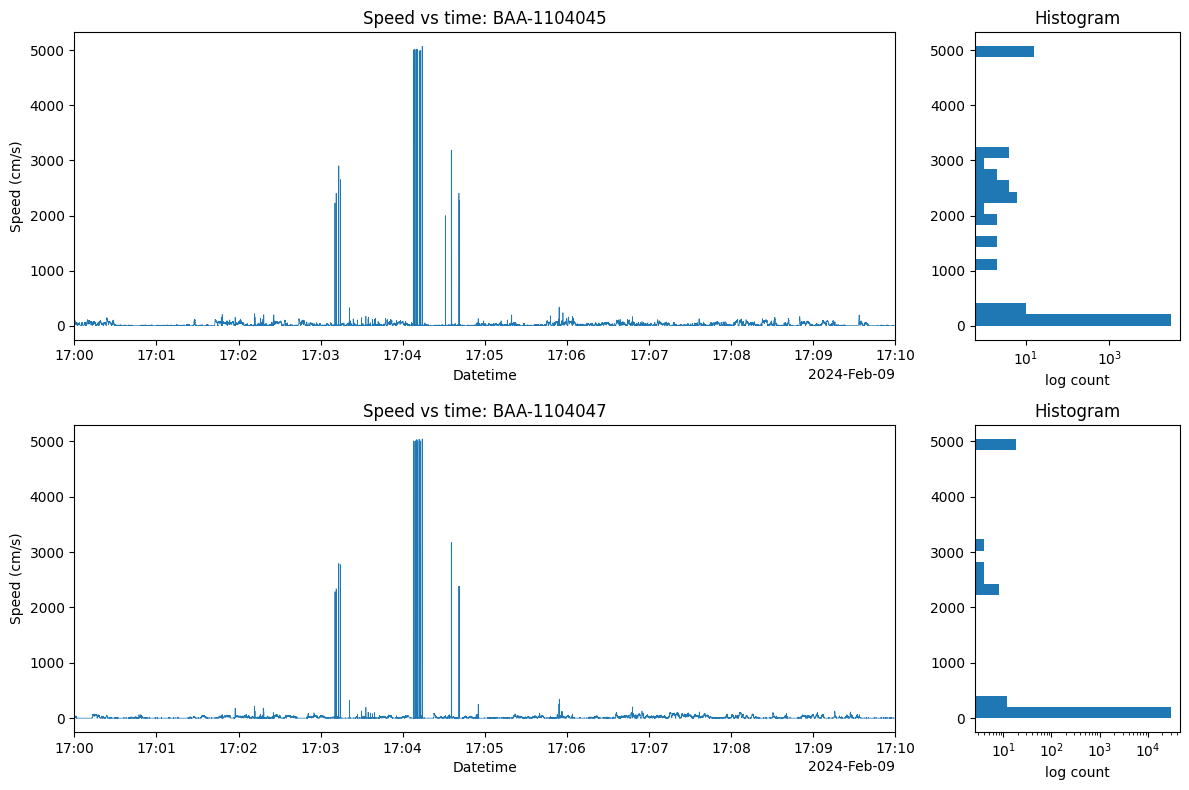

In [341]:
plot_speed(ds.speed_cm_per_sec_smooth.sel(keypoints="spine2"))

### Plot all keypoints speed per individual

#### Filtered data points with confidence >= 0.6

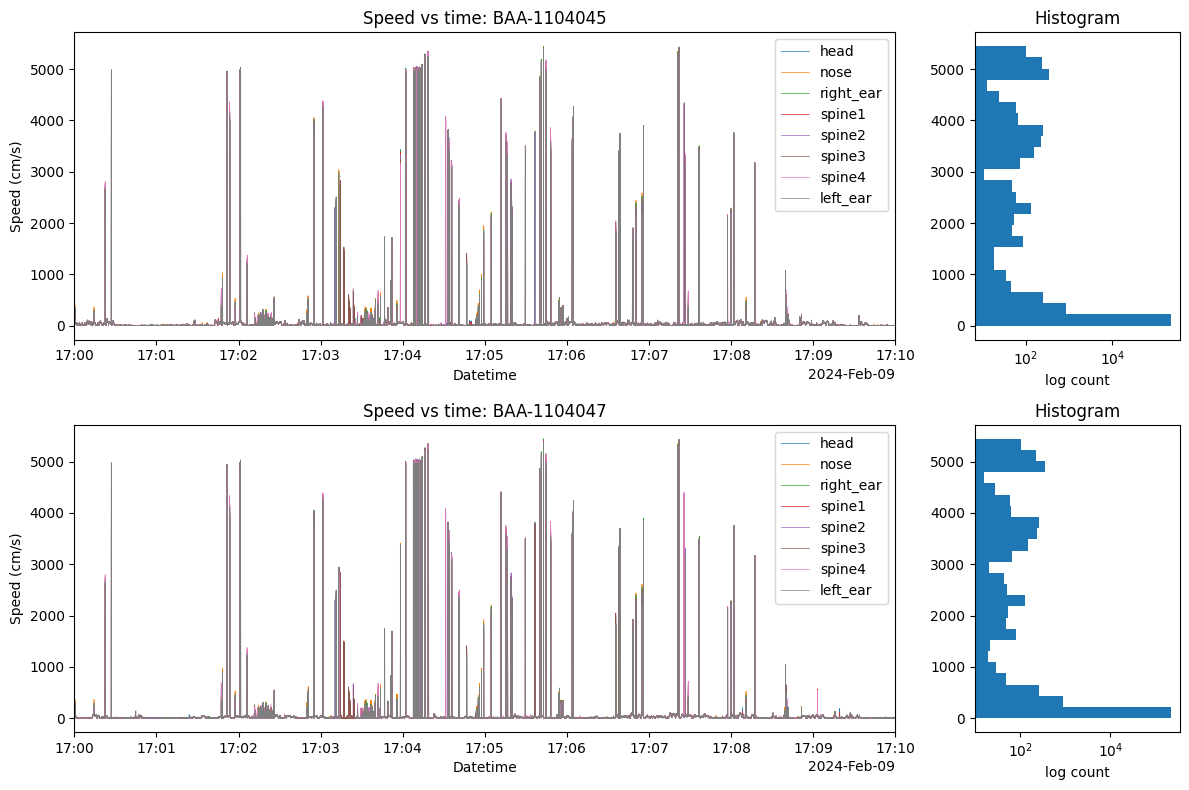

In [344]:
plot_speed(ds.speed_cm_per_sec)

#### Filtered data points with confidence >= 0.6 and median smoothing

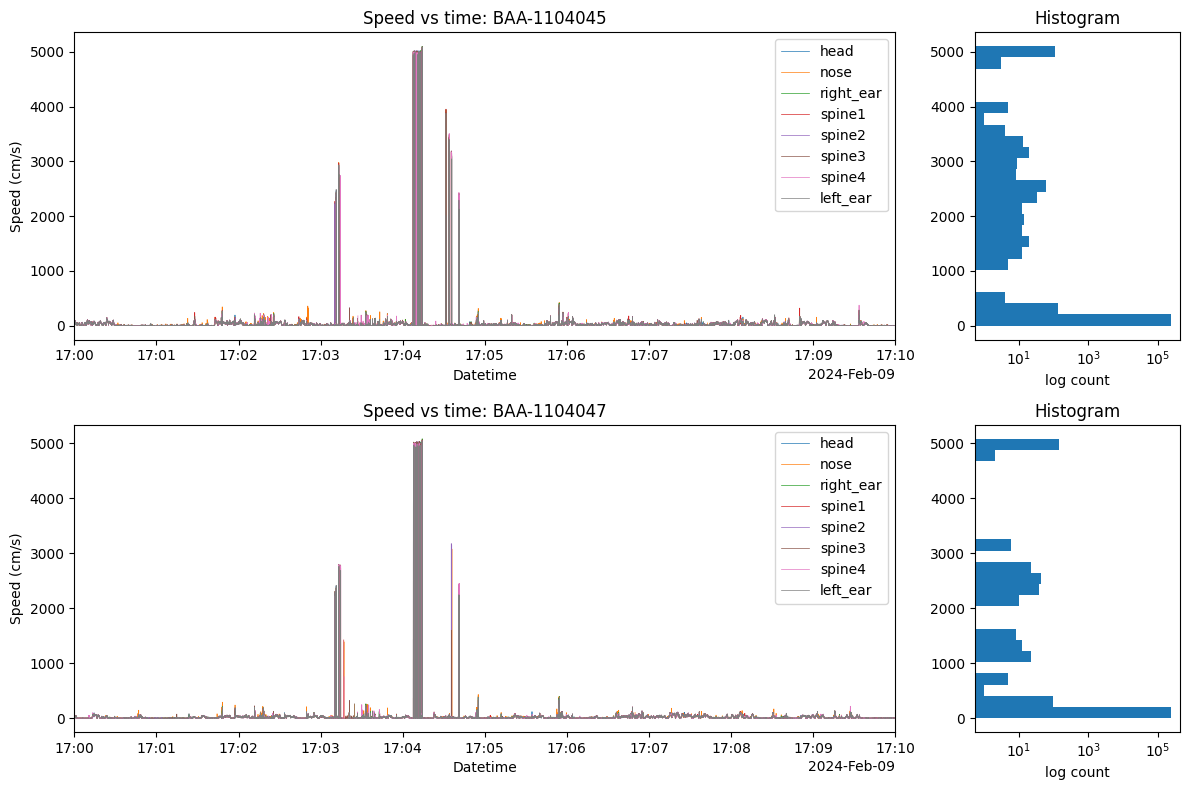

In [345]:
plot_speed(ds.speed_cm_per_sec_smooth)

## Plot centroid trajectory 

By default, centroid is computed as the mean of all keypoints. 
This can be changed by setting `keypoint` either to a single keypoint or a list of keypoints in ``plot_centroid_trajectory``.

In [184]:
# Load background image
background_img = plt.imread("social02aeon3.png")
height, width = background_img.shape[:2]

### Centroid as the mean of all keypoints
#### Filtered data points with confidence >= 0.6

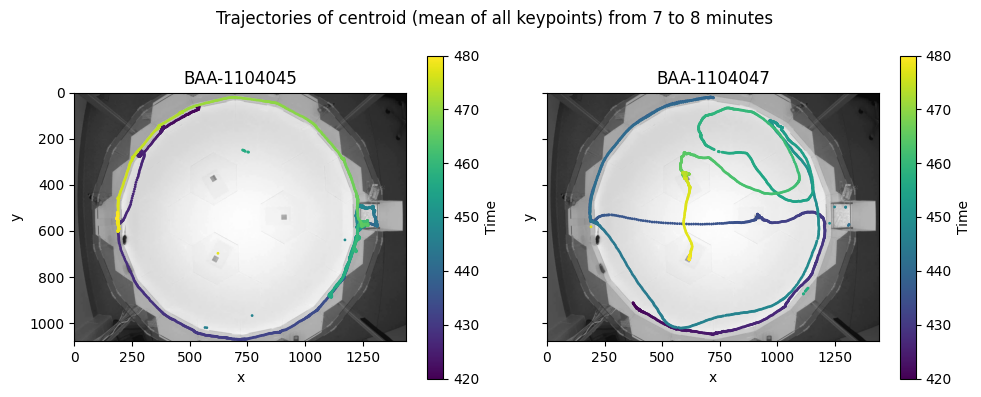

In [346]:
# Select 7-8th minute of data
time_window = slice(7 * 60, 8 * 60)
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for i, mouse in enumerate(ds.individuals.values):
    ax[i].imshow(background_img)
    plot_centroid_trajectory(
        ds.position_filtered.set_index(time="seconds_elapsed").sel(time=time_window),
        individual=mouse,
        s=1,
        ax=ax[i],
    )
    ax[i].set_title(f"{mouse}")
    ax[i].set_ylim([height - 1, 0])
    ax[i].set_xlim([0, width])
plt.suptitle("Trajectories of centroid (mean of all keypoints) from 7 to 8 minutes")
plt.tight_layout()
plt.show()

#### Filtered data points with confidence >= 0.6 and median smoothing

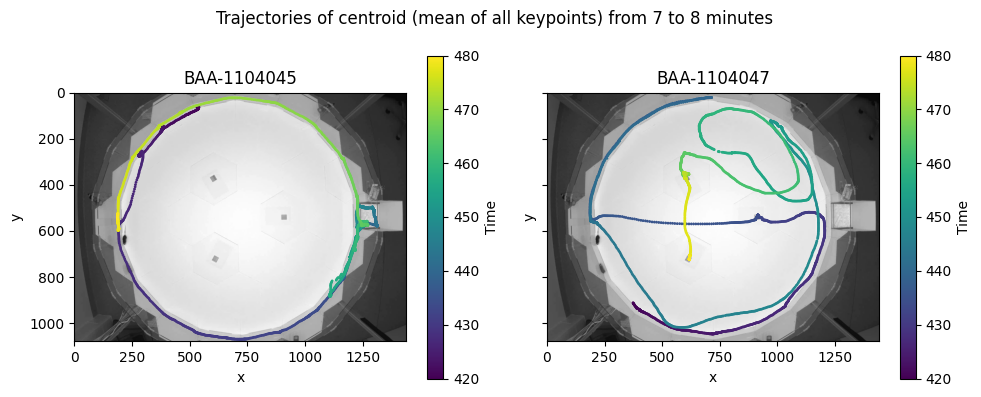

In [347]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for i, mouse in enumerate(ds.individuals.values):
    ax[i].imshow(background_img)
    plot_centroid_trajectory(
        ds.position_smooth.set_index(time="seconds_elapsed").sel(time=time_window),
        individual=mouse,
        s=1,
        ax=ax[i],
    )
    ax[i].set_title(f"{mouse}")
    ax[i].set_ylim([height - 1, 0])
    ax[i].set_xlim([0, width])
plt.suptitle("Trajectories of centroid (mean of all keypoints) from 7 to 8 minutes")
plt.tight_layout()
plt.show()

### Centroid as a single point `spine2`

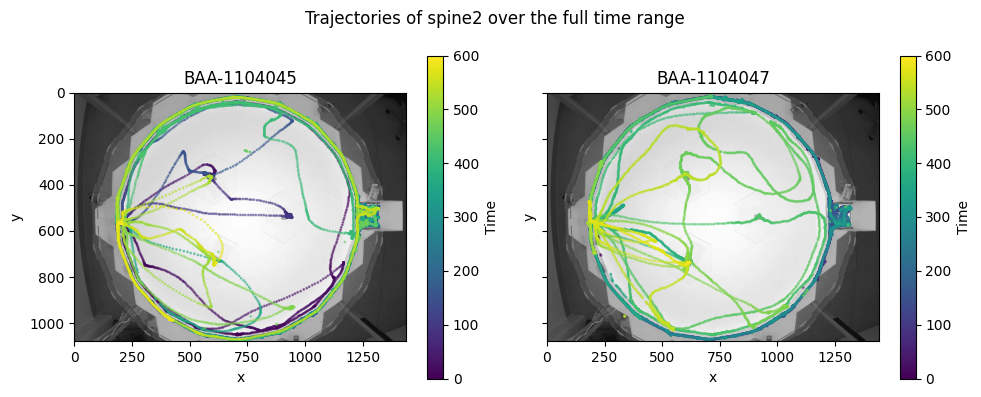

In [360]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for i, mouse in enumerate(ds.individuals.values):
    ax[i].imshow(background_img)
    plot_centroid_trajectory(
        ds.position_filtered.set_index(time="seconds_elapsed"),
        individual=mouse,
        keypoints="spine2",
        s=1,
        alpha=0.5,
        ax=ax[i],
    )
    ax[i].set_title(f"{mouse}")
    ax[i].set_ylim([height - 1, 0])
    ax[i].set_xlim([0, width])
plt.suptitle("Trajectories of spine2 over the full time range")
plt.tight_layout()
plt.show()

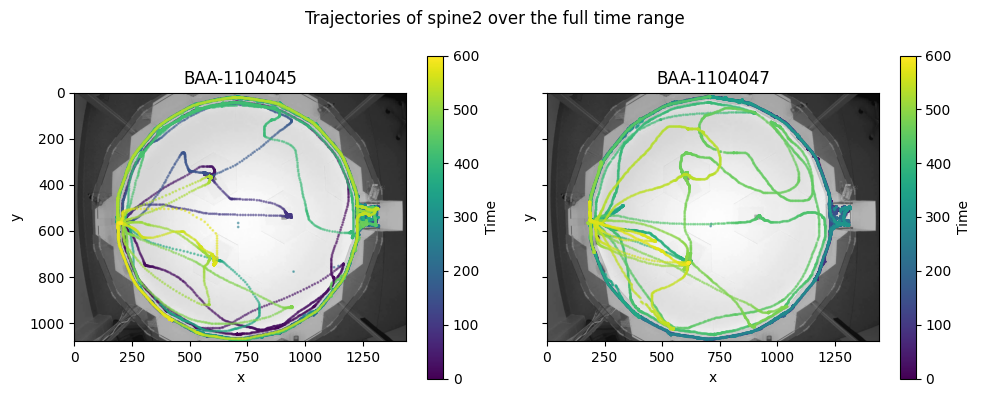

In [359]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for i, mouse in enumerate(ds.individuals.values):
    ax[i].imshow(background_img)
    plot_centroid_trajectory(
        ds.position_smooth.set_index(time="seconds_elapsed"),
        individual=mouse,
        keypoints="spine2",
        s=1,
        alpha=0.5,
        ax=ax[i],
    )
    ax[i].set_title(f"{mouse}")
    ax[i].set_ylim([height - 1, 0])
    ax[i].set_xlim([0, width])
plt.suptitle("Trajectories of spine2 over the full time range")
plt.tight_layout()
plt.show()

## Plot occupancy heatmap

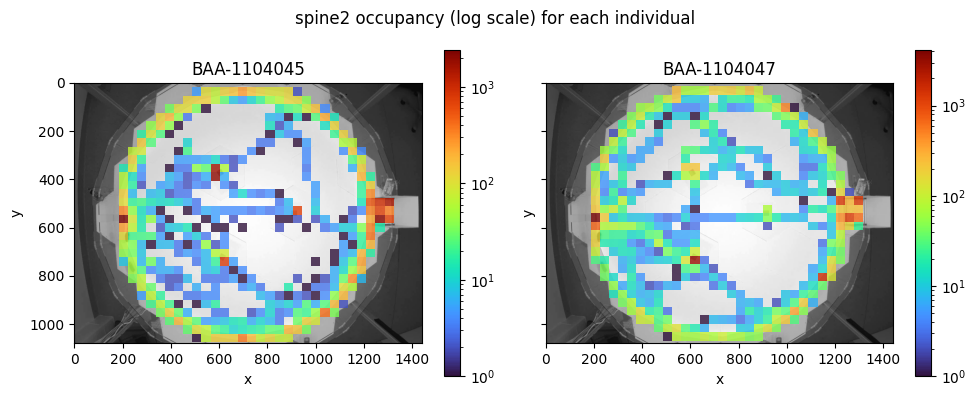

In [350]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for i, mouse in enumerate(ds.individuals.values):
    ax[i].imshow(background_img)
    plot_occupancy(
        ds.position_smooth.sel(individuals=mouse).set_index(time="seconds_elapsed"),
        ax=ax[i],
        cmap="turbo",
        norm="log",
        alpha=0.8,
        bins=30,
    )
    ax[i].set_title(f"{mouse}")
    ax[i].set_ylim([height - 1, 0])
    ax[i].set_xlim([0, width])
plt.suptitle("spine2 occupancy (log scale) for each individual")
plt.tight_layout()
plt.show()

## Plot head-to-nose vector for a single individual

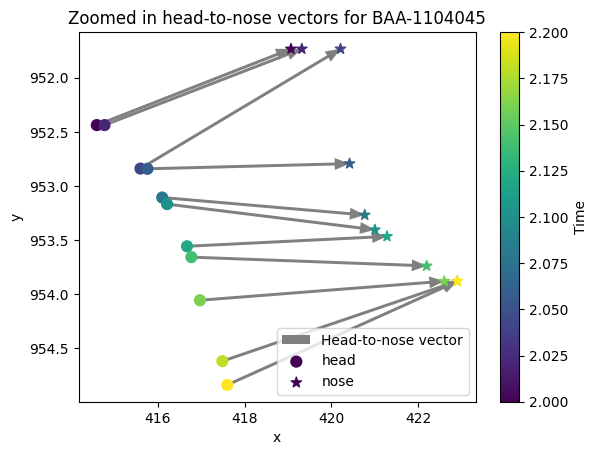

In [381]:
# Compute the head vector as the difference vector between the nose and the head
individual = ds.individuals.values[0]  # Select the first individual for demonstration
nose = ds.position_smooth.sel(keypoints="nose", individuals=individual, drop=True).set_index(time="seconds_elapsed")
head = ds.position_smooth.sel(keypoints="head", individuals=individual, drop=True).set_index(time="seconds_elapsed")
head_to_nose = nose - head
# Restrict the plot to a specific time window for better visibility
time_window = slice(2, 2.2)  # seconds
fig, ax = plt.subplots()
# Plot the computed head-to-nose vector originating from the head
ax.quiver(
    head.sel(space="x", time=time_window),
    head.sel(space="y", time=time_window),
    head_to_nose.sel(space="x", time=time_window),
    head_to_nose.sel(space="y", time=time_window),
    color="gray",
    angles="xy",
    scale=1,
    scale_units="xy",
    headwidth=4,
    headlength=5,
    headaxislength=5,
    label="Head-to-nose vector",
)
# Plot head within the time window
plot_centroid_trajectory(
    head.sel(time=time_window),
    ax=ax,
    s=60,
    label="head",
)
# Plot the nose position within the time window
plot_centroid_trajectory(
    nose.sel(time=time_window),
    ax=ax,
    s=60,
    marker="*",
    label="nose",
)
# Calling plot_centroid_trajectory twice will add 2 identical colorbars
# so we remove 1
ax.collections[2].colorbar.remove()
ax.set_title(f"Zoomed in head-to-nose vectors for {individual}")
ax.invert_yaxis()  # invert y-axis to match image coordinates
ax.legend(loc="lower right")

### Convert to polar coordinates

**Note** 

`rho` is the norm (i.e., magnitude, length) of the vector. 
Here this is the distance from the head to the nose.

`phi` angle is positive if the rotation from the positive x-axis to the vector is in the same direction as the rotation from the positive x-axis to the positive y-axis. 
In the default image coordinate system (where top left corner is the origin 0,0), `phi` will be positive if the rotation is clockwise, and negative if the rotation is anti-clockwise.

In [ ]:
head_to_nose_polar = cart2pol(head_to_nose)
head_to_nose_polar

<xarray.DataArray 'position_smooth' (time: 30001, space_pol: 2)> Size: 480kB
7.125 0.6808 7.125 0.6808 7.125 0.6808 ... -0.6056 7.38 -0.6054 7.38 -0.6054
Coordinates:
  * time       (time) float64 240kB 0.0 0.02 0.04 0.06 ... 600.0 600.0 600.0
  * space_pol  (space_pol) <U3 24B 'rho' 'phi'

### Estimate head-to-nose vector using `left_ear` and `right_ear` keypoints

If `head` and `nose` keypoints are not reliable, we can estimate the head-to-nose vector using `left_ear` and `right_ear` keypoints (vector perpendicular to the midpoint of the left and right ears).

In [387]:
forward_vector = compute_forward_vector(
    ds.position_smooth,
    left_keypoint="left_ear",
    right_keypoint="right_ear",
    camera_view="top_down",
)
forward_vector_angle = compute_forward_vector_angle(
    ds.position_smooth,
    left_keypoint="left_ear",
    right_keypoint="right_ear",
    camera_view="top_down",
    in_degrees=False,  # set to True for degrees
)

## Plot head direction angles

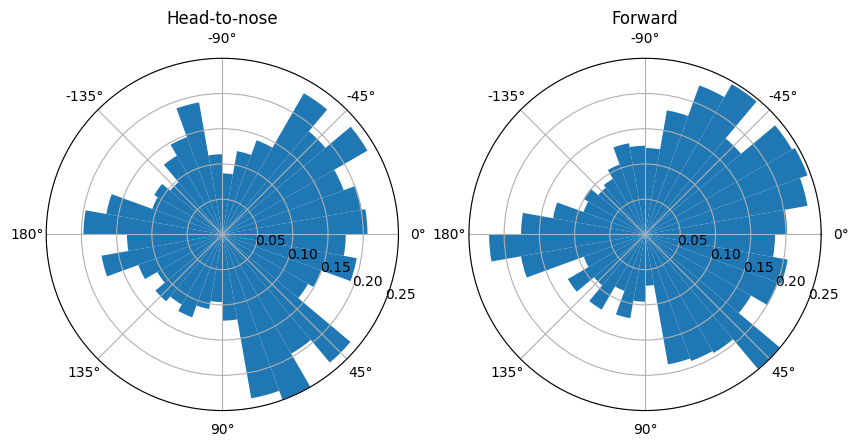

In [ ]:
head_to_nose_angle = head_to_nose_polar.sel(space_pol="phi")
angle_arrays = [head_to_nose_angle, forward_vector_angle]
angle_titles = ["Head-to-nose", "Forward"]

fig, axes = plt.subplots(
    head_to_nose_angle.individuals.size, 2, figsize=(10, 5), subplot_kw={"projection": "polar"}
)
for i, angles in enumerate(angle_arrays):
    title = angle_titles[i]
    ax = axes[i]
    plot_polar_histogram(angles, bin_width_deg=10, ax=ax)
    ax.set_ylim(0, 0.25)  # force same y-scale (density) for both plots
    ax.set_title(title, pad=25)

Text(0.5, 1.0, 'Forward vector angle - head-to-nose angle')

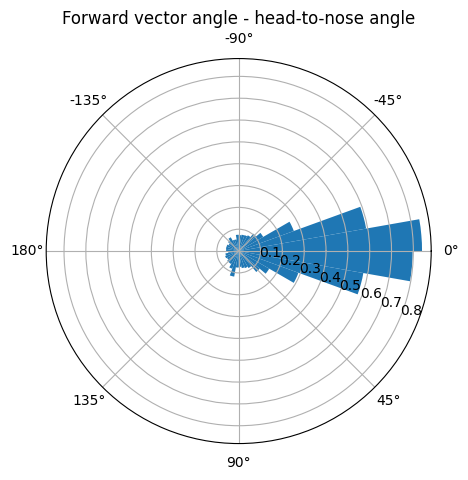

In [ ]:
# Visualise difference between forward vector angle and head-to-nose angle
angles_diff = forward_vector_angle.set_index(time="seconds_elapsed") - head_to_nose_angle
fig, ax = plot_polar_histogram(angles_diff, bin_width_deg=10)
ax.set_title("Forward vector angle - head-to-nose angle", pad=25)

## Plot pairwise distances between keypoints

In [405]:
ds["dist_euclidean"] = compute_pairwise_distances(
    ds.position_smooth,
    dim="individuals",
    pairs="all",
    metric="euclidean",
)

### Pairwise distances between every pairs of keypoints between the two individuals

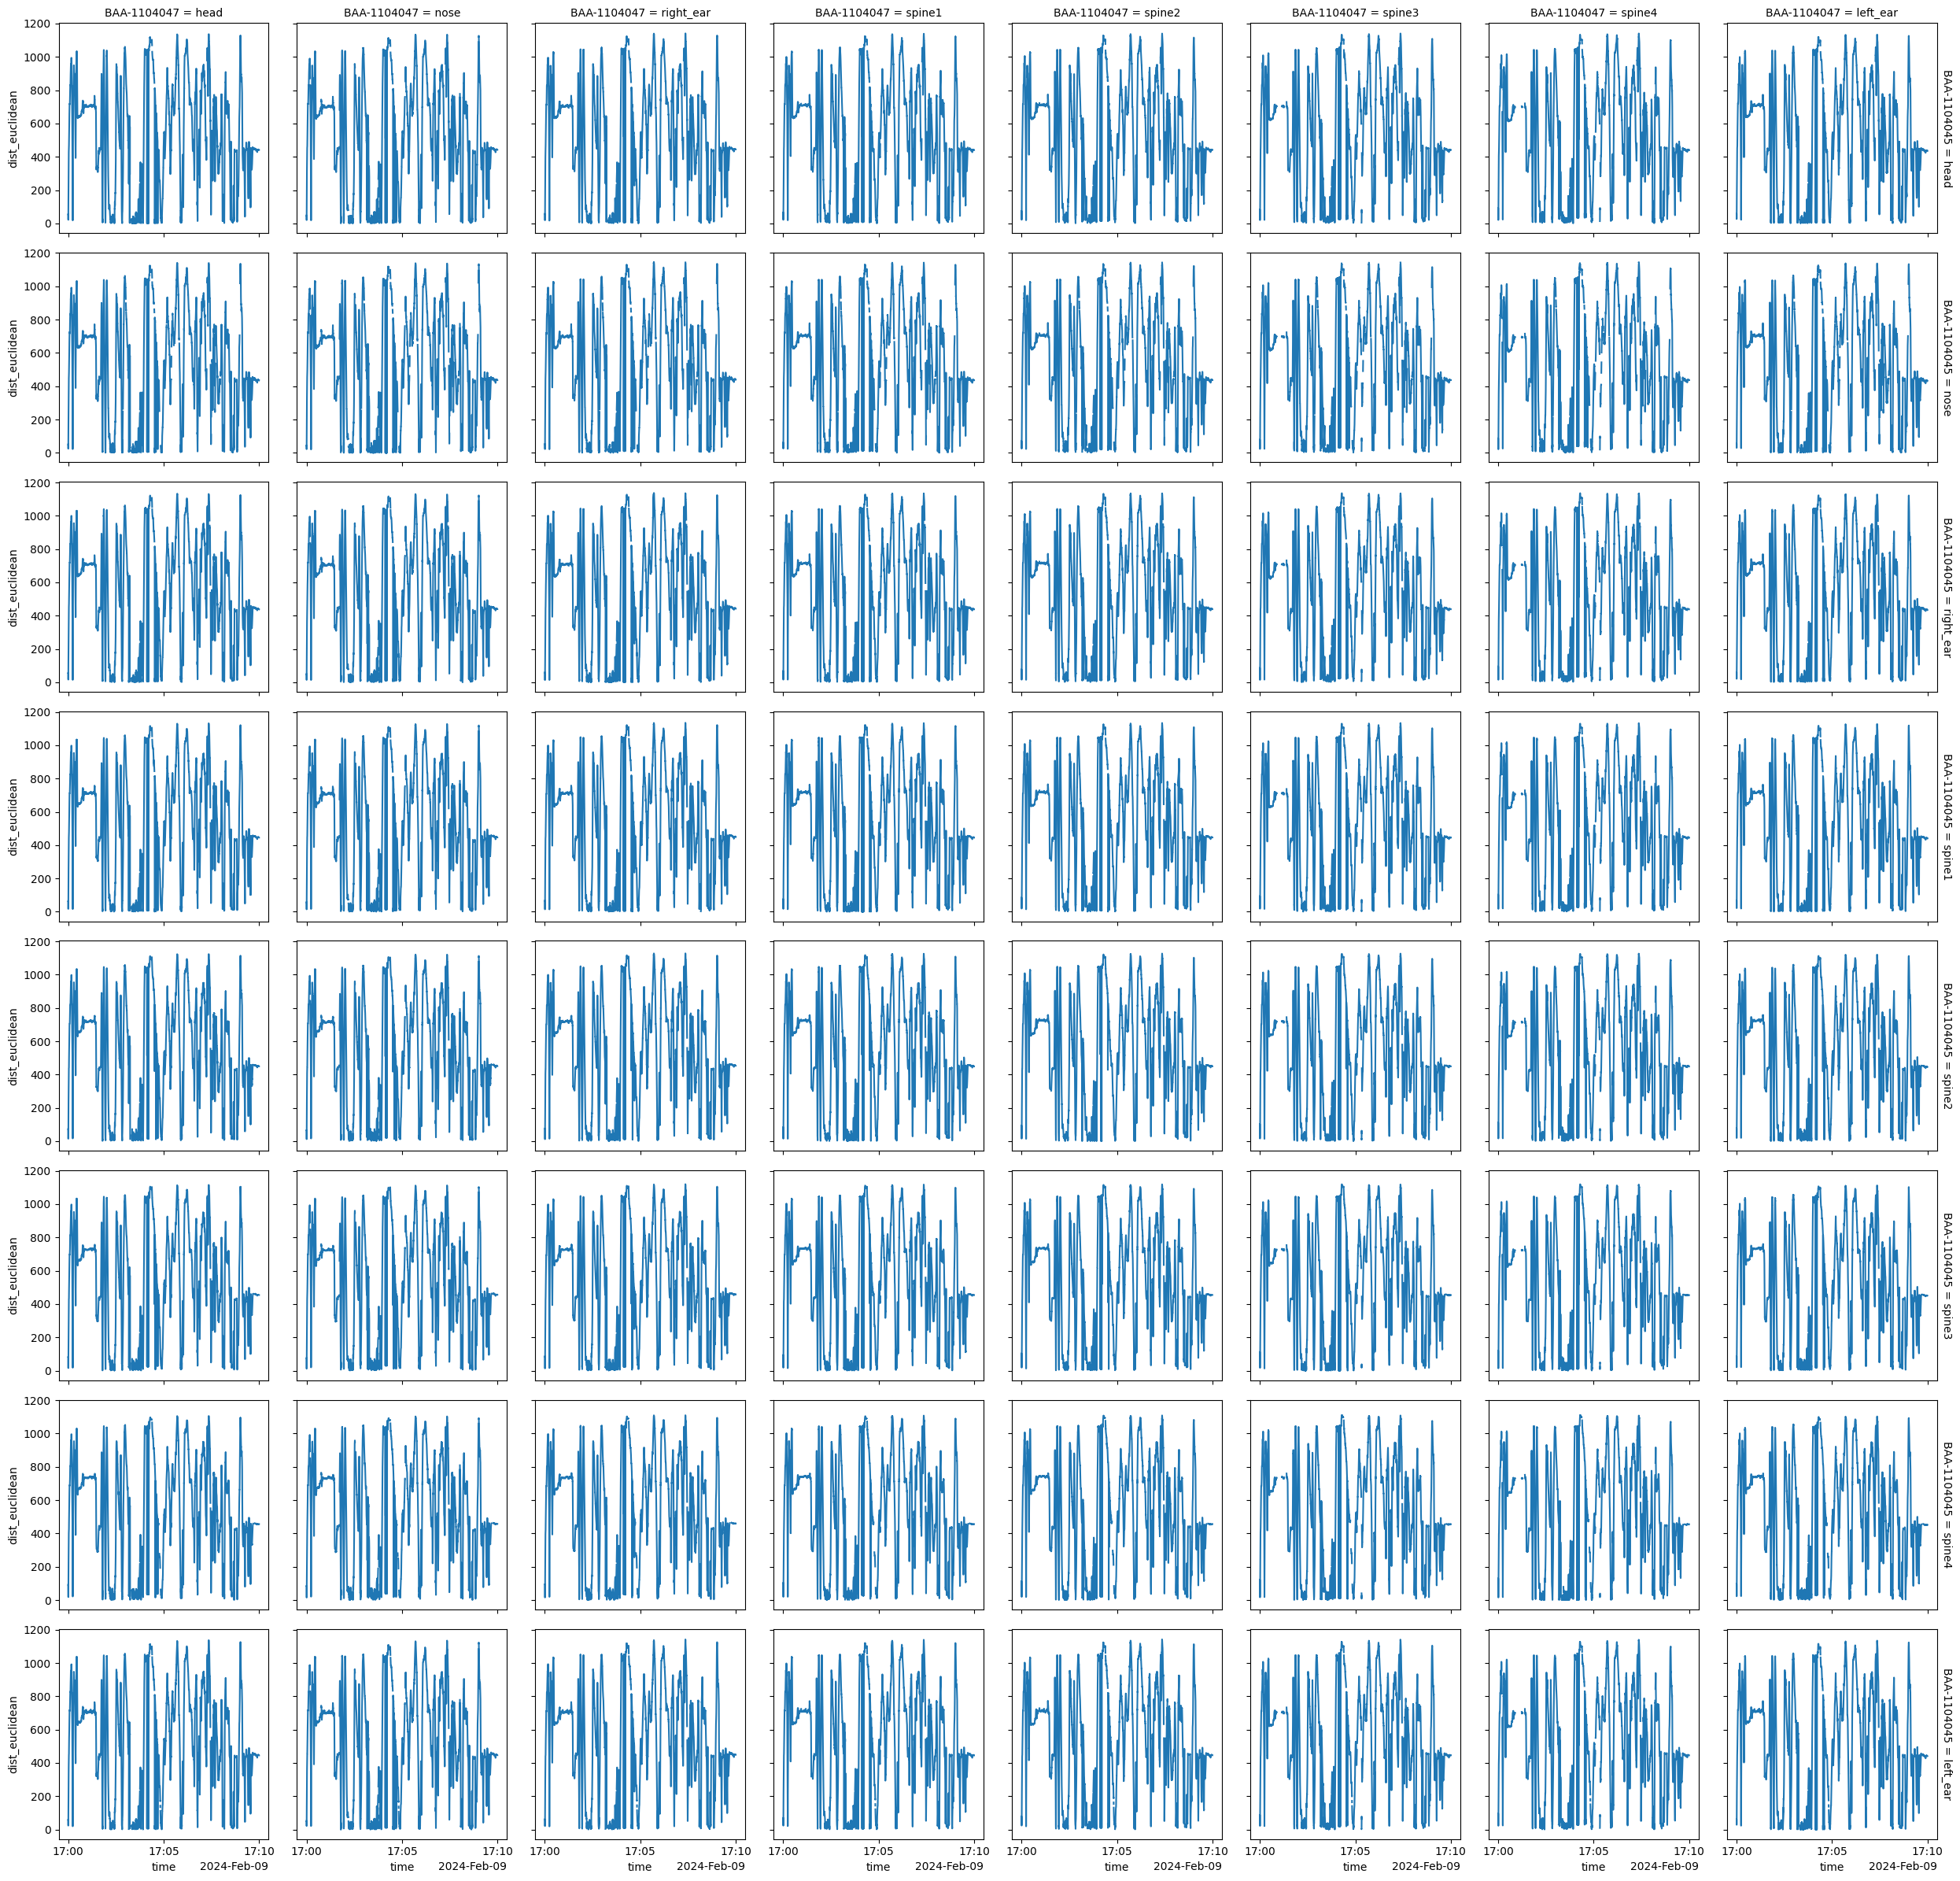

In [419]:
ds.dist_euclidean.plot.line(
    x="time",
    row="BAA-1104045",
    col="BAA-1104047",
)

### Distance between noses of BAA-1104045 and BAA-1104047

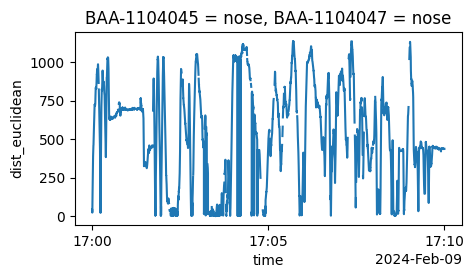

In [ ]:
ds.dist_euclidean.sel({"BAA-1104045": "nose", "BAA-1104047": "nose"}).plot.line(
    x="time",
    aspect=2,
    size=2.5
)


### Distance between nose of BAA-1104045 and spine4 of BAA-1104047

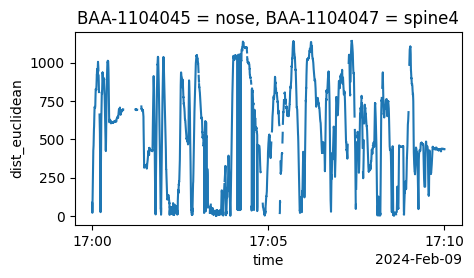

In [ ]:
ds.dist_euclidean.sel({"BAA-1104045": "nose", "BAA-1104047": "spine4"}).plot.line(
    x="time",
    aspect=2,
    size=2.5
)